# Exploratory Data Analysis (EDA)

## Objective

The objective of this stage is to explore the dataset visually and statistically in order to identify patterns, relatioships and insights that may help explain customer churn.

The analysis in this notebook will be performed on train set in order to prevent from any data leakage.

The findings from this analysis will guide the data preprocessing and feature engineering steps.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
file_name = '../data/processed/train.csv'
train_df = pd.read_csv(file_name)

In [3]:
train_df.shape

(5634, 20)

### Convert Senior Citizen into Categorical Feature

The `SeniorCitizen` feature is numeric binary 0/1. For better representation we convert it into categorical binary Yes/No.

In [4]:
train_df['SeniorCitizen'] = train_df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

## Numerical Feature Analysis

In this section, the numerical features are explored using histograms and box plots to understand their distributions and identify potential outliers.

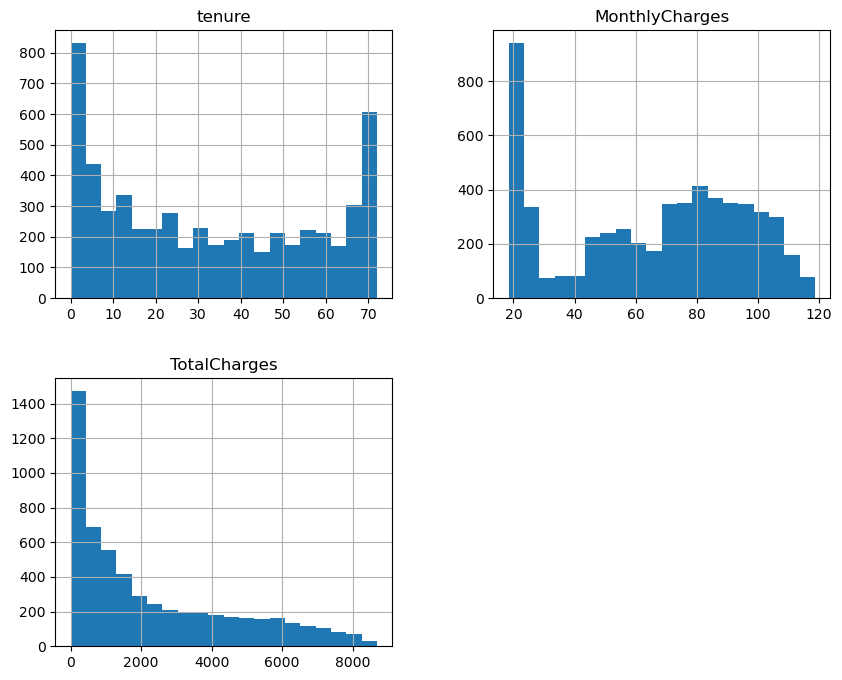

In [5]:
train_df.hist(bins = 20, figsize=(10, 8))
plt.show()

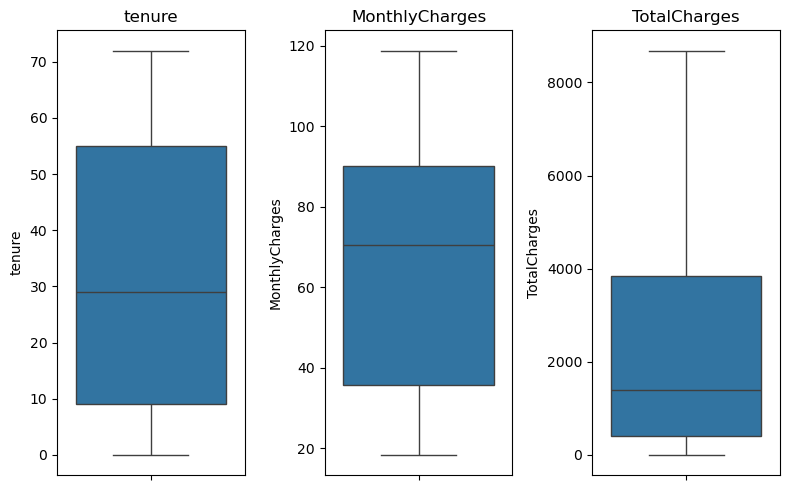

In [6]:
num_cols = train_df.select_dtypes('number').columns.tolist()
fig, axes = plt.subplots(1, 3, figsize=(8, 5))
for col, ax in zip(num_cols, axes.flat):
    sns.boxplot(
        data=train_df,
        y=col,
        ax=ax
    )
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Categorical Feature Analysis

Understanding the distribution of categorical variables helps identify dominant categories, detect potential data imbalance and gain insights into customer characteristics before analyzing their relationship with churn.

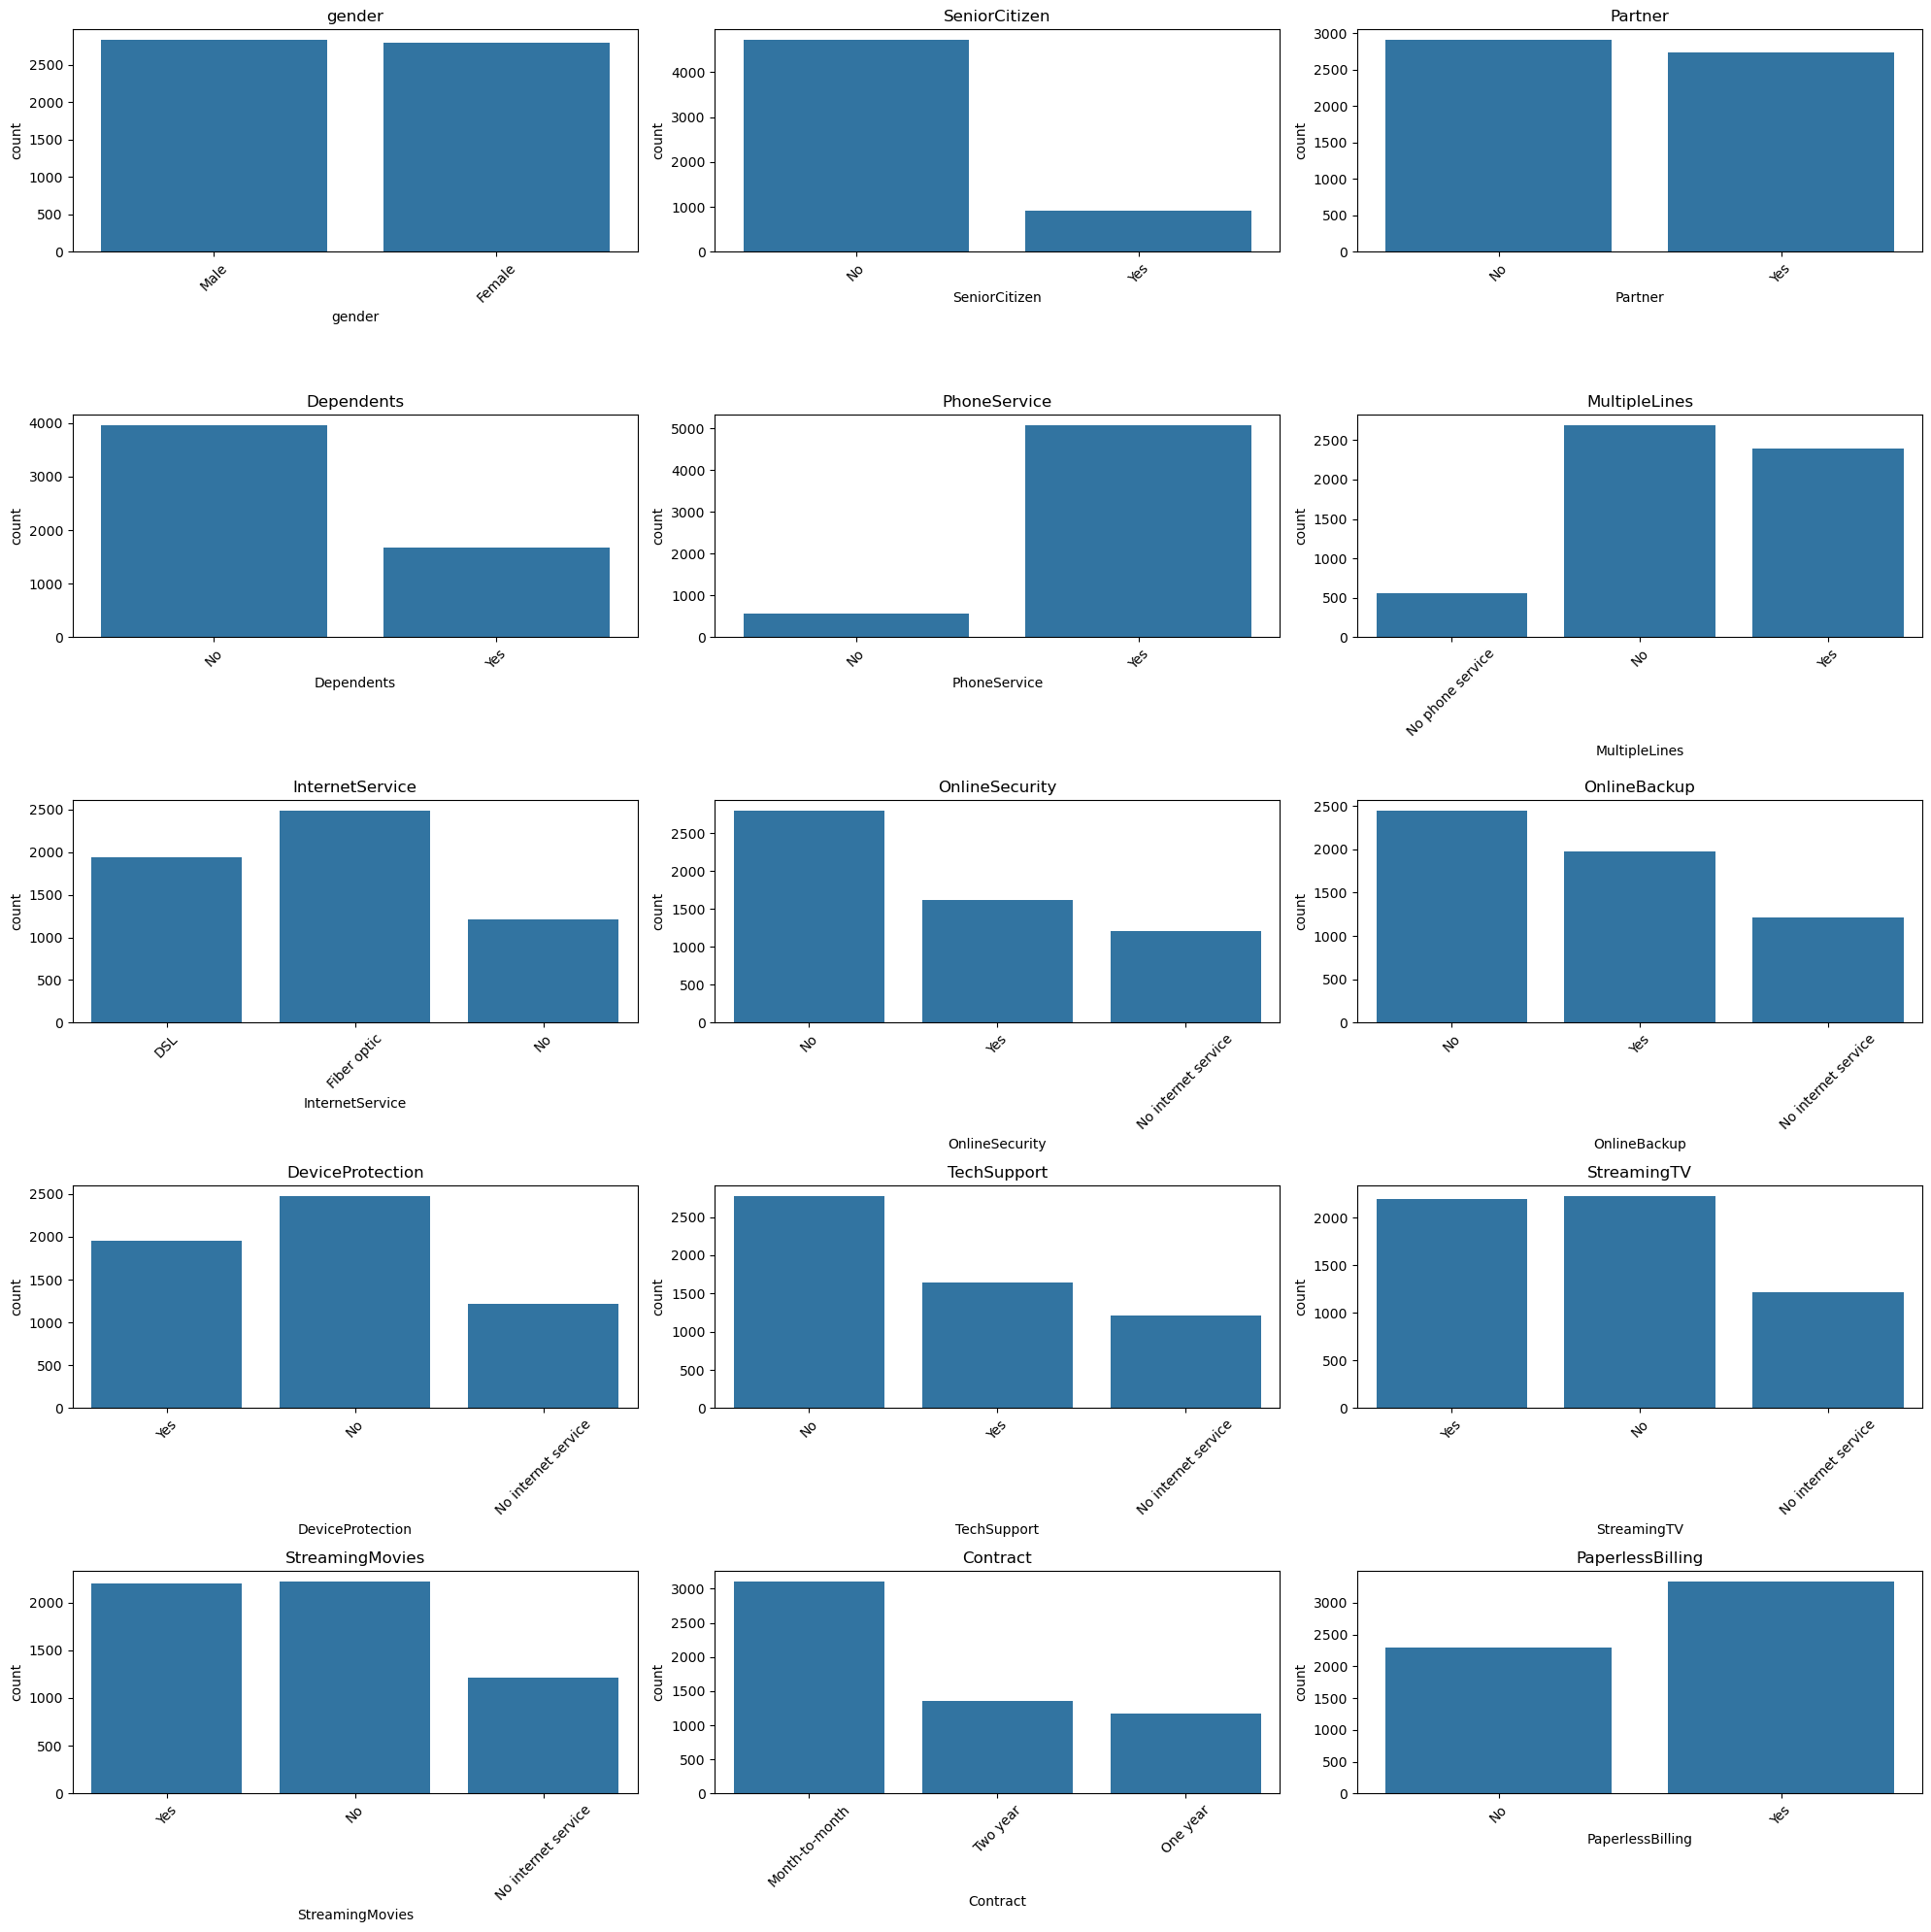

In [7]:
cat_cols = train_df.select_dtypes('object').columns.tolist()
cat_cols.remove('Churn')
fig, axes = plt.subplots(5, 3, figsize=(20, 20))
for col, ax in zip(cat_cols, axes.flat):
    sns.countplot(
        data=train_df,
        x=col,
        ax=ax
    )
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Churn Distribution

In this section we analyze the distribution of target variable.

In [8]:
churn_count = pd.DataFrame({
    'Count': train_df['Churn'].value_counts(),
    'Percentage': train_df['Churn'].value_counts(normalize=True)
})
churn_count

,Count,Percentage
Churn,,
No,4139,0.734647
Yes,1495,0.265353


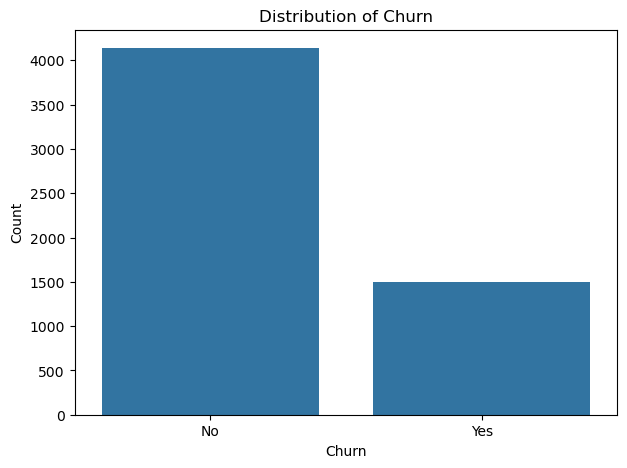

In [9]:
plt.figure(figsize=(7, 5))
sns.countplot(data=train_df, x='Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Distribution of Churn')
plt.show()

## Feature Relationship with Churn

In this section we explore the relationship between customer features and the target variable `Churn`.
The objective is to identify patterns that may help explain customer churn and provide useful insights for predictive modeling.

In [10]:
pd.crosstab(train_df['Contract'], train_df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,1776,1326
One year,1043,130
Two year,1320,39


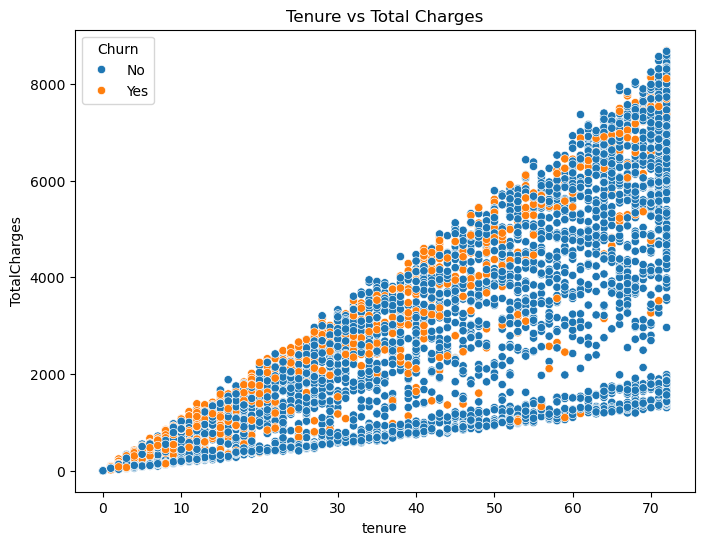

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=train_df,
    x='tenure',
    y='TotalCharges',
    hue='Churn'
)
plt.title('Tenure vs Total Charges')
plt.show()

## EDA Summary

Based on the exploratory data analysis, several important patterns were identified:

- The target variable `Churn` is imbalanced with fewer churned customers compared to retained customers.
- Customers with shorter tenure appear to have a higher tendency to churn, while long-term customers are more likely to stay.
- Contract type shows a strong relationship with churn. Customers with monthly contracts have higher churn compared to customers with long-term contracts.
- Customers who churned are more frequently associated with the absence of additional services such as OnlineSecurity and TechSupport.
- Fiber optic internet service appears frequently among churned customers and requires further investigations.
- Electronic check is the most common payment method among churned customers.
- Customers who churned generally have lower total charges, although some hugh-value customers also churned.

